# Stage 5 — SHAP Explainability (Revenue Ensemble)

**Mục tiêu:**
- Tính SHAP values cho ensemble revenue model (LightGBM + CatBoost)
- Visualise: Summary plot (global importance), Bar plot, Dependence plots
- Phân tích top features và feature importance
- Lưu plots: `shap_summary_rev.png`, `shap_bar_rev.png`, `shap_dependence_rev.png`

**Inputs:** `lgbm_rev.pkl`, `catboost_rev.cbm`, `features_ready.csv`, `feature_meta.json`  
**Outputs:** SHAP plots

In [1]:
import pandas as pd
import numpy as np
import json
import pickle
import os
import warnings
import shap
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from catboost import CatBoostRegressor
from pathlib import Path

warnings.filterwarnings('ignore')
shap.initjs()

BASE_DIR = Path().resolve()
OUTPUT_DIR = BASE_DIR / 'output'
print(f'SHAP version: {shap.__version__}')
print('Libraries loaded ✓')

d:\push_code\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.51.0
Libraries loaded ✓


## 1. Load Models & Data

In [2]:
# Load feature metadata
with open(os.path.join(OUTPUT_DIR, 'feature_meta.json')) as f:
    meta = json.load(f)

# Load data
df = pd.read_csv(os.path.join(OUTPUT_DIR, 'features_ready.csv'), parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
train = df[df['split'] == 'train'].copy().reset_index(drop=True)

# Load LightGBM and CatBoost Revenue models
lgbm_rev = pickle.load(open(os.path.join(OUTPUT_DIR, 'lgbm_rev.pkl'), 'rb'))
catboost_rev = CatBoostRegressor()
catboost_rev.load_model(os.path.join(OUTPUT_DIR, 'catboost_rev.cbm'))

# Use the feature order expected by the trained models
FEATURE_COLS = list(lgbm_rev.booster_.feature_name())
missing_cols = [c for c in FEATURE_COLS if c not in train.columns]
if 'prophet_yhat' in missing_cols:
    prophet_rev = pickle.load(open(os.path.join(OUTPUT_DIR, 'prophet_rev.pkl'), 'rb'))
    extra_regs = list(prophet_rev.extra_regressors.keys())
    future_df = pd.DataFrame({'ds': train['date']})
    for reg in extra_regs:
        future_df[reg] = train[reg].values
    forecast = prophet_rev.predict(future_df)
    train['prophet_yhat'] = forecast['yhat'].values
    print('Regenerated prophet_yhat from prophet_rev.pkl ✓')
    missing_cols = [c for c in FEATURE_COLS if c not in train.columns]
if missing_cols:
    print(f'WARNING: Missing columns from train set: {missing_cols}')

X_train = train[FEATURE_COLS].copy()
IMG_DIR = os.path.join(OUTPUT_DIR, 'report', 'images')
os.makedirs(IMG_DIR, exist_ok=True)

print(f'Train data: {X_train.shape}')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Image directory: {IMG_DIR}')
print('LightGBM and CatBoost Revenue models loaded ✓')

Regenerated prophet_yhat from prophet_rev.pkl ✓
Train data: (3833, 69)
Features: 69
Image directory: D:\push_code\Phan 3 Mo hinh Du bao Doanh thu\output\report\images
LightGBM and CatBoost Revenue models loaded ✓


In [3]:
# Inspect loaded LightGBM and CatBoost feature expectations
print('LightGBM feature count:', len(lgbm_rev.booster_.feature_name()))
print('LightGBM feature names:', lgbm_rev.booster_.feature_name())
print('CatBoost has feature_names_?:', hasattr(catboost_rev, 'feature_names_'))
print('CatBoost has get_feature_names?:', hasattr(catboost_rev, 'get_feature_names'))
if hasattr(catboost_rev, 'get_feature_names'):
    try:
        print('CatBoost feature names:', catboost_rev.get_feature_names())
    except Exception as e:
        print('Could not get CatBoost feature names:', e)


LightGBM feature count: 69
LightGBM feature names: ['n_active_promos', 'avg_discount_value', 'has_promo', 'rev_lag_7', 'rev_lag_14', 'rev_lag_21', 'rev_lag_28', 'rev_lag_30', 'rev_lag_60', 'rev_lag_90', 'rev_lag_180', 'rev_lag_365', 'rev_lag7_vs_lag14', 'rev_lag7_vs_lag28', 'rev_lag7_vs_lag365', 'rev_roll_mean_7', 'rev_roll_std_7', 'rev_roll_min_7', 'rev_roll_max_7', 'rev_roll_mean_14', 'rev_roll_std_14', 'rev_roll_min_14', 'rev_roll_max_14', 'rev_roll_mean_30', 'rev_roll_std_30', 'rev_roll_min_30', 'rev_roll_max_30', 'rev_roll_mean_90', 'rev_roll_std_90', 'rev_roll_min_90', 'rev_roll_max_90', 'year', 'month', 'day', 'day_of_week', 'day_of_year', 'quarter', 'week_of_year', 'is_weekend', 'is_month_end', 'is_month_start', 'is_quarter_end', 'is_year_end', 'is_year_start', 'is_peak_season', 'is_low_season', 'year_trend', 'post_2019', 'post_2020', 'days_since_start', 'sin_weekly_n1', 'cos_weekly_n1', 'sin_weekly_n2', 'cos_weekly_n2', 'sin_weekly_n3', 'cos_weekly_n3', 'sin_yearly_n1', 'cos_y

## 2. Compute SHAP Values — Revenue Ensemble

In [4]:
print('Computing SHAP values for Revenue ensemble ...')

# Ensemble weights from Stage 4 optimization
w_lgbm = 0.556
w_catboost = 0.444

def ensemble_predict(X):
    X = pd.DataFrame(X, columns=FEATURE_COLS)
    preds_lgbm = lgbm_rev.predict(X)
    preds_catboost = catboost_rev.predict(X)
    return w_lgbm * preds_lgbm + w_catboost * preds_catboost

# Use a smaller background sample for KernelExplainer speed
X_background = X_train.sample(n=min(100, len(X_train)), random_state=42)
explainer_rev = shap.KernelExplainer(ensemble_predict, X_background)

X_sample = X_train.tail(500).reset_index(drop=True)
shap_values_rev = explainer_rev.shap_values(X_sample, nsamples=100)

print(f'SHAP values shape: {np.array(shap_values_rev).shape}')
print('Done ✓')

Computing SHAP values for Revenue ensemble ...


100%|██████████| 500/500 [00:24<00:00, 20.46it/s]

SHAP values shape: (500, 69)
Done ✓


## 3. SHAP Summary Plot — Revenue

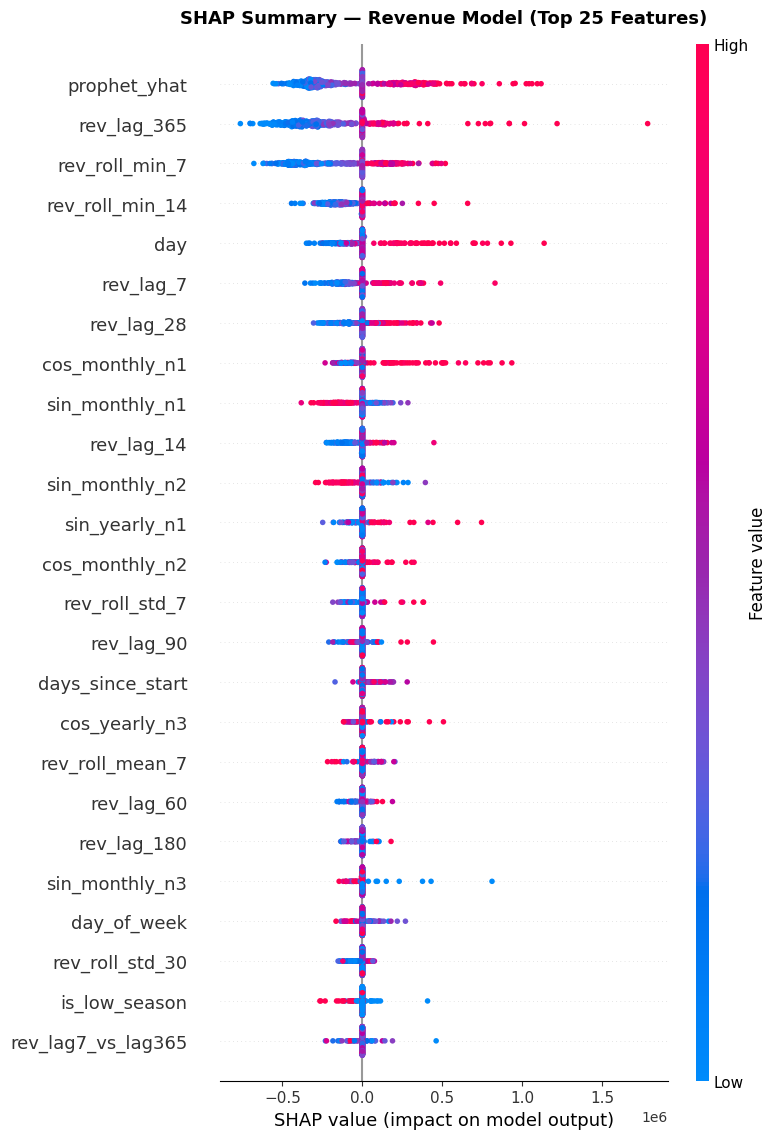

D:\push_code\Phan 3 Mo hinh Du bao Doanh thu\output\report\images\shap_summary_rev.png saved


In [5]:
plt.figure(figsize=(10, 12))
shap.summary_plot(
    shap_values_rev, X_sample,
    plot_type='dot',
    max_display=25,
    show=False
)
plt.title('SHAP Summary — Revenue Model (Top 25 Features)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'shap_summary_rev.png'), dpi=150, bbox_inches='tight')
plt.show()
print(os.path.join(IMG_DIR, 'shap_summary_rev.png'), 'saved')

## 4. SHAP Bar Plot — Revenue (Mean |SHAP|)

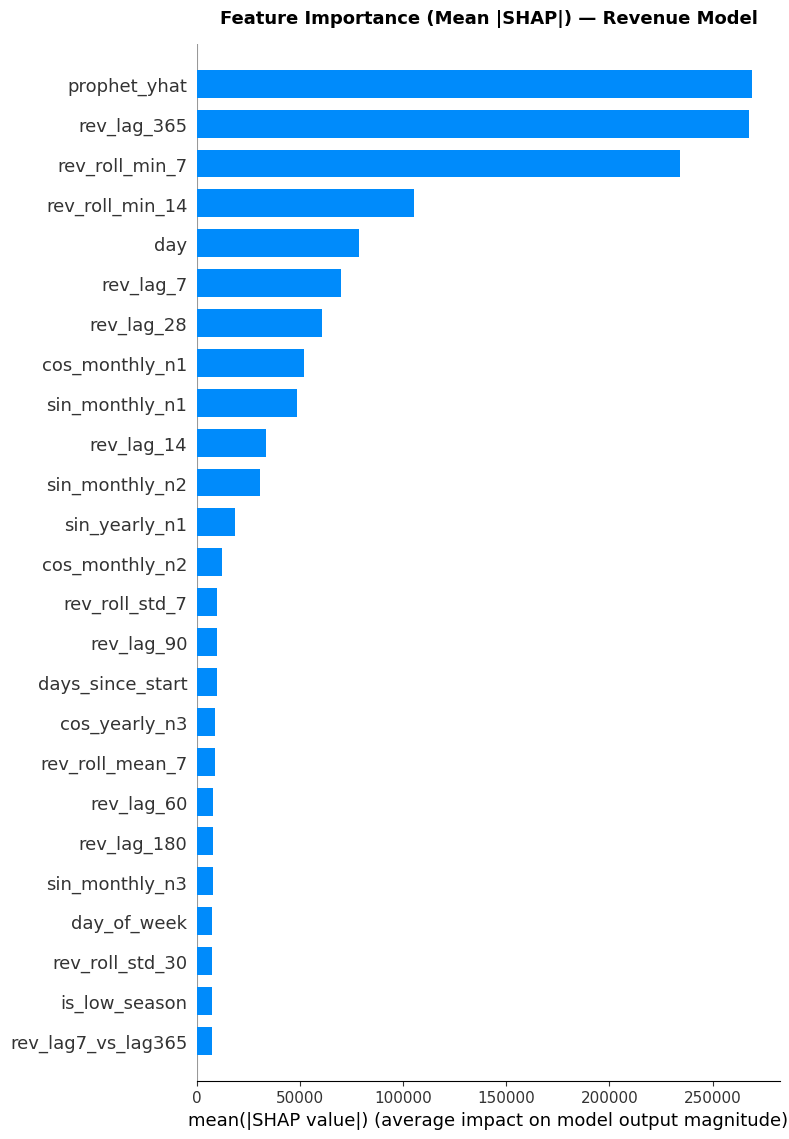

D:\push_code\Phan 3 Mo hinh Du bao Doanh thu\output\report\images\shap_bar_rev.png saved


In [6]:
plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values_rev, X_sample,
    plot_type='bar',
    max_display=25,
    show=False
)
plt.title('Feature Importance (Mean |SHAP|) — Revenue Model', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'shap_bar_rev.png'), dpi=150, bbox_inches='tight')
plt.show()
print(os.path.join(IMG_DIR, 'shap_bar_rev.png'), 'saved')

## 5. Feature Importance — Revenue Model

In [7]:
# Compute mean |SHAP| for Revenue model
mean_shap_rev = np.abs(shap_values_rev).mean(axis=0)
imp_rev = pd.DataFrame({'feature': FEATURE_COLS, 'mean_shap': mean_shap_rev})
imp_rev = imp_rev.sort_values('mean_shap', ascending=False).reset_index(drop=True)

# Save CSV
imp_rev.to_csv(os.path.join(OUTPUT_DIR, 'shap_importance_rev.csv'), index=False)

print('Top 15 Revenue Features (Mean |SHAP|):')
print(imp_rev.head(15).to_string(index=False))

Top 15 Revenue Features (Mean |SHAP|):
        feature     mean_shap
   prophet_yhat 269253.002425
    rev_lag_365 267873.572372
 rev_roll_min_7 234000.097736
rev_roll_min_14 105412.257459
            day  78405.291487
      rev_lag_7  69669.816904
     rev_lag_28  60659.823129
 cos_monthly_n1  51953.569396
 sin_monthly_n1  48252.048556
     rev_lag_14  33482.881998
 sin_monthly_n2  30666.283205
  sin_yearly_n1  18501.521548
 cos_monthly_n2  11845.870041
 rev_roll_std_7   9817.327639
     rev_lag_90   9718.565518


## 6. SHAP Dependence Plots — Top Features

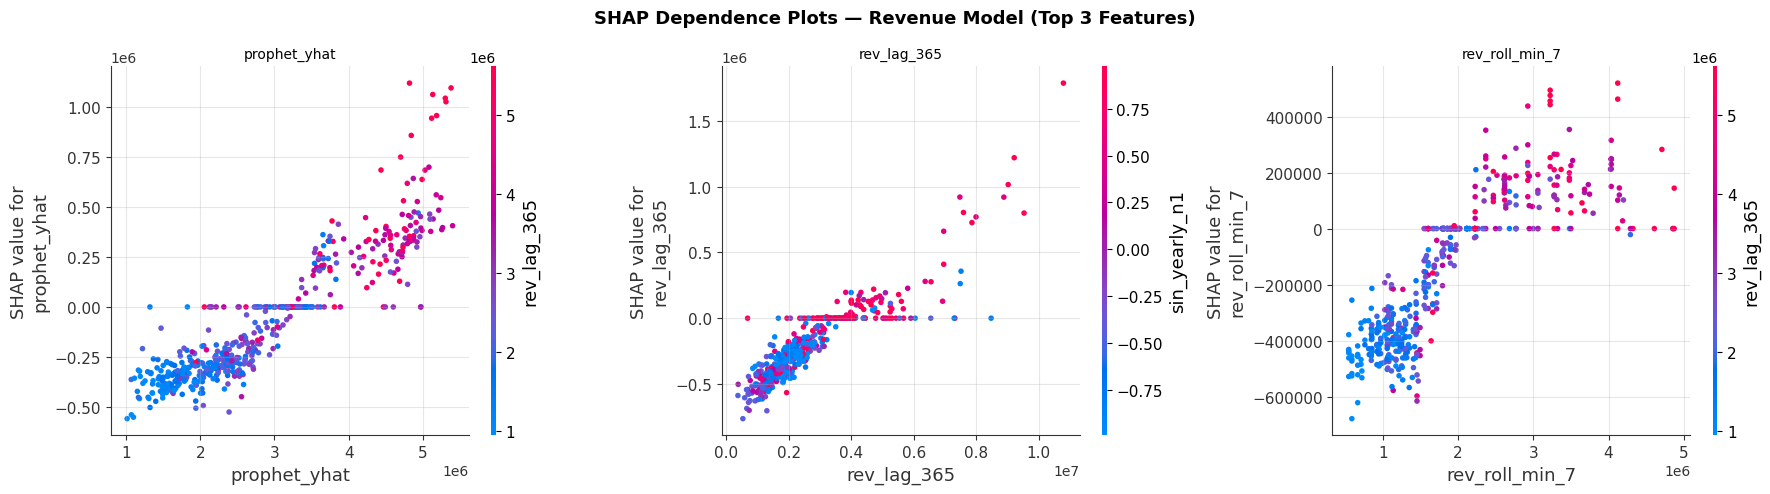

D:\push_code\Phan 3 Mo hinh Du bao Doanh thu\output\report\images\shap_dependence_rev.png saved


In [8]:
top3_rev = imp_rev.head(3)['feature'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SHAP Dependence Plots — Revenue Model (Top 3 Features)', fontsize=13, fontweight='bold')

for i, feat in enumerate(top3_rev):
    feat_idx = list(X_sample.columns).index(feat)
    shap.dependence_plot(
        feat, shap_values_rev, X_sample,
        ax=axes[i], show=False
    )
    axes[i].set_title(feat, fontsize=10)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, 'shap_dependence_rev.png'), dpi=150, bbox_inches='tight')
plt.show()
print(os.path.join(IMG_DIR, 'shap_dependence_rev.png'), 'saved')

## 7. Summary

In [9]:
print('=' * 65)
print('STAGE 5 COMPLETE — SHAP Explainability (Revenue Model)')
print('=' * 65)
print()
print('Outputs:')
print('  - shap_summary_rev.png      (dot plot, top 25 features)')
print('  - shap_bar_rev.png          (bar plot, mean |SHAP|)')
print('  - shap_dependence_rev.png   (dependence, top 3 features)')
print('  - shap_importance_rev.csv   (all features sorted by importance)')
print()
print('Top 5 Most Important Features:')
for i, row in imp_rev.head(5).iterrows():
    print(f'  {i+1}. {row["feature"]:30s} SHAP={row["mean_shap"]:12,.0f}')

STAGE 5 COMPLETE — SHAP Explainability (Revenue Model)

Outputs:
  - shap_summary_rev.png      (dot plot, top 25 features)
  - shap_bar_rev.png          (bar plot, mean |SHAP|)
  - shap_dependence_rev.png   (dependence, top 3 features)
  - shap_importance_rev.csv   (all features sorted by importance)

Top 5 Most Important Features:
  1. prophet_yhat                   SHAP=     269,253
  2. rev_lag_365                    SHAP=     267,874
  3. rev_roll_min_7                 SHAP=     234,000
  4. rev_roll_min_14                SHAP=     105,412
  5. day                            SHAP=      78,405
